# Cross-validation et courbe d'apprentissage

## Le problème : comment régler les hyperparamètres « honnêtement » ?

Quand on veut **améliorer** un modèle en jouant sur ses hyperparamètres (`max_depth`, `min_samples_leaf`, `C` d'une SVM, `learning_rate` d'un boosting...), il faut bien pouvoir **comparer** plusieurs choix et garder le meilleur. Mais sur quelles données comparer ?

- ❌ **Pas sur le jeu d'apprentissage** : un modèle plus complexe aura toujours un meilleur score train (il suffit de le laisser overfitter). Ça ne dit rien sur sa qualité réelle.
- ❌ **Pas sur le jeu de test** : le test représente les « données inconnues », celles qu'on n'a pas vues. Si on utilise le test pour **choisir** nos hyperparamètres, on est en train de *s'adapter* au test, et on perd son rôle de juge impartial. Un modèle qu'on a tuné sur le test ne dira plus rien d'honnête sur sa généralisation.

> **Analogie :** le jeu de test, c'est l'examen final. Si tu le regardes avant l'examen pour t'entraîner dessus, ton 20/20 ne veut plus rien dire — tu as triché. Le jeu de test doit rester **scellé** jusqu'à la toute fin.

## La solution : un 3e jeu, dit **de validation**

On sépare donc les données en **trois** paquets :
1. **Train** : sert à entraîner le modèle.
2. **Validation** : sert à comparer différents choix d'hyperparamètres et choisir le meilleur.
3. **Test** : sert **une seule fois**, à la toute fin, pour estimer la performance réelle du modèle choisi.

C'est ce qu'on met en place dans ce notebook, puis on verra que la **cross-validation** permet de faire cette même chose de manière plus efficace et plus fiable.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [2]:
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
X.shape

(442, 10)

## Jeu de test

On met de côté **25% des données** (le *test set*) — et on y touche plus avant la toute fin. Ce paquet représente les « données jamais vues » et ne sert qu'à la mesure finale, **une seule fois**, pour un verdict honnête.

In [3]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.25, random_state=2
)

## Jeux d'apprentissage et de validation

Sur les 75% restants (le « train_full »), on extrait encore 33% (soit ≈ 25% du total) comme **jeu de validation**. Il servira à comparer plusieurs configurations d'hyperparamètres et à choisir la meilleure **sans jamais toucher au test**.

**Récap de la répartition :**
- 50% → train (apprentissage)
- 25% → validation (choix des hyperparamètres)
- 25% → test (verdict final)

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.33, random_state=2
)

## Expérimentation

On entraîne un premier modèle avec une configuration donnée d'hyperparamètres, puis on mesure ses performances **sur le jeu de validation** pour savoir si cette configuration est bonne. En pratique, on répéterait cette étape pour plusieurs configurations et on garderait celle qui a le meilleur score de validation.

In [5]:
tree_reg = DecisionTreeRegressor(max_depth=4, max_features=5, random_state=2)
tree_reg.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, max_features=5, random_state=2)

### Évaluation du modèle

On compare le score **train** et le score **validation**. L'écart entre les deux est notre baromètre d'overfitting.

In [6]:
y_pred = tree_reg.predict(X_train)
r2_score(y_train, y_pred)

0.6337729052225081

In [7]:
y_pred = tree_reg.predict(X_val)
r2_score(y_val, y_pred)

0.21319468333614966

#### DecisionTreeRegressor(autres-hyperparamètres)

Ici, en pratique, on essaierait plusieurs configurations : `max_depth=2`, `max_depth=6`, `min_samples_leaf=5`... et on garderait celle qui donne le meilleur **score de validation**.

### Autre algorithme

On ferait la même chose avec un autre algo (Random Forest, Gradient Boosting, Ridge...) pour comparer. L'idée est que le **jeu de validation** sert de juge pour **tous** les candidats — train pour apprendre, validation pour comparer, test pour le verdict final.

## Test des modèles — le verdict final

Une fois les hyperparamètres optimisés sur la validation, on peut **enfin** regarder le test. Un seul chiffre, une seule fois : c'est l'**estimation honnête** de ce que donnera le modèle en production.

> ⚠️ **Attention** : si le test donne un résultat décevant, la tentation est de retourner ajuster les hyperparamètres... mais en faisant ça, le test perd son statut de juge impartial (on a triché). La rigueur veut qu'on accepte le verdict ou qu'on reparte de plus loin (nouveau problème, plus de données, nouvelles features...).

In [8]:
y_pred = tree_reg.predict(X_test)
r2_score(y_test, y_pred)

-0.045219289320064915

### Limites de cette approche

**Deux problèmes majeurs :**

1. **On gaspille des données pour la validation.** Ici, 25% du jeu ne sert ni à l'apprentissage ni au test final. Sur un petit dataset comme `diabetes` (442 points), ça fait mal : on prive le modèle d'un quart de ses données d'entraînement.

2. **Le score de validation est instable.** Il dépend du *hasard* du split — on a eu de la chance ou pas, selon les patients qui sont tombés dans la validation. Changez `random_state` et le score peut bouger significativement. Un seul chiffre peu fiable sur lequel on prend des décisions d'architecture, c'est risqué.

**La cross-validation résout ces deux problèmes d'un coup.**

## Cross-validation

**L'idée :** au lieu de choisir *un seul* découpage train/validation au hasard, on en fait **plusieurs**, et on fait la moyenne des scores de validation obtenus. On gagne en **fiabilité** (moyenne sur plusieurs essais au lieu d'un tirage chanceux) et en **efficience** (chaque donnée sert tour à tour à l'entraînement ET à la validation).

### Le principe du k-fold

On découpe le jeu d'entraînement en $k$ morceaux (*folds*) de taille égale. Puis on répète $k$ fois l'expérience :

- **Itération 1** : on entraîne sur les folds 2, 3, 4, 5 et on valide sur le fold 1.
- **Itération 2** : on entraîne sur les folds 1, 3, 4, 5 et on valide sur le fold 2.
- **Itération 3** : on entraîne sur les folds 1, 2, 4, 5 et on valide sur le fold 3.
- ... et ainsi de suite.

À la fin, on a $k$ scores de validation. On les résume par :
- leur **moyenne** → le score attendu du modèle ;
- leur **écart-type** → la *stabilité* du modèle (un fort écart-type est un signal d'alarme : le modèle est sensible aux données sur lesquelles il est entraîné).

> **Le bénéfice :** chaque donnée sert **une fois** à la validation et **$k-1$ fois** à l'entraînement. On utilise *toutes* les données pour apprendre et pour valider.

![Cross validation](https://scikit-learn.org/stable/_images/grid_search_cross_validation.png)

Voir la [documentation scikit-learn](https://scikit-learn.org/stable/modules/cross_validation.html).

### Mise en œuvre dans scikit-learn

`cross_val_score` fait tout le travail pour nous : on lui passe un modèle non-entraîné, les données, une métrique et un nombre de folds $k$, et il renvoie les $k$ scores de validation.

#### Jeu d'apprentissage et de test

Le test set reste indispensable — même avec la cross-validation. La cross-validation remplace le **jeu de validation**, pas le **jeu de test**. On garde donc environ 15% pour le test final (inchangé), et on fera la cross-validation sur les 85% restants.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=2
)

#### Calcul des scores sur 10 folds

On demande `cv=10` : 10 découpages, donc 10 scores de validation.

In [10]:
X.shape, X_train.shape, X_test.shape

((442, 10), (375, 10), (67, 10))

In [11]:
from sklearn.model_selection import cross_val_score

tree_reg = DecisionTreeRegressor(max_depth=4, max_features=5, random_state=2)

tree_r2_scores = cross_val_score(
    tree_reg, X_train, y_train, scoring="r2", cv=10
)
tree_r2_scores

array([ 0.12760162,  0.30276536,  0.18162368,  0.41454927,  0.47294672,
        0.30880572,  0.31275944, -0.0079007 ,  0.45209936,  0.42697687])

In [12]:
tree_r2_scores.mean(), tree_r2_scores.std()

(0.2992227329484779, 0.14868368776207272)

## Courbe d'apprentissage

**L'idée :** entraîner le même modèle sur des **sous-échantillons de tailles croissantes** du jeu d'apprentissage, et tracer le score (sur train et sur validation, via cross-validation) en fonction de la taille.

> **Intuition :** cette courbe permet de répondre à une question cruciale :
>
> *« Est-ce que mon modèle profiterait d'avoir plus de données à manger, ou bien est-ce que j'ai atteint son plafond intrinsèque ? »*

On aura une **courbe train** et une **courbe validation** (souvent appelée « courbe de test » ou « cross-validation »). La façon dont ces deux courbes évoluent et se rapprochent (ou non) nous dit tout sur l'état du modèle.

### Comment lire une courbe d'apprentissage ?

- **Les deux courbes se rapprochent à un niveau élevé** → 🎉 le modèle est bien paramétré, plus de données pourraient un peu aider mais ne sont pas urgentes.
- **Les deux courbes plafonnent à un niveau bas** et sont proches l'une de l'autre → **underfitting** : le modèle est trop simple, plus de données ne changeront rien. Il faut un modèle plus complexe (ou de meilleures features).
- **Grand écart entre train (haut) et validation (bas)** qui ne se réduit pas avec plus de données → **overfitting** : il faut régulariser ou simplifier le modèle.
- **Grand écart qui se réduit à mesure que la taille augmente** → **plus de données aiderait** effectivement ; c'est un bon signal pour investir dans la collecte.

In [13]:
tree_reg = DecisionTreeRegressor(max_depth=4, max_features=3, random_state=2)

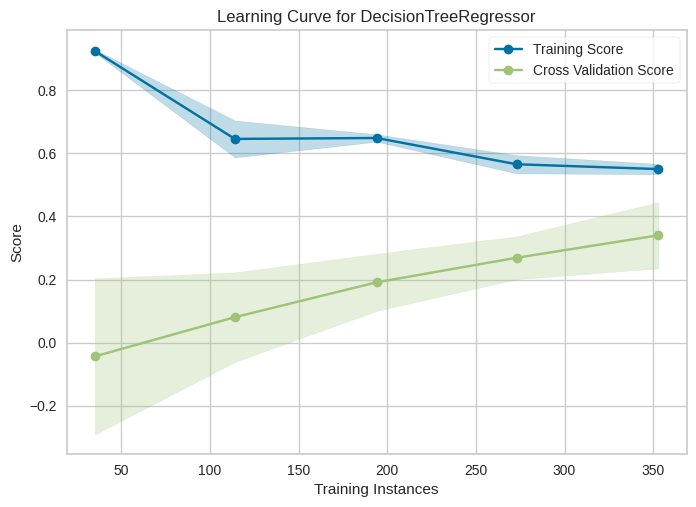

In [14]:
from yellowbrick.model_selection import LearningCurve

visualizer = LearningCurve(tree_reg, scoring='r2')
visualizer.fit(X, y)
visualizer.show();

In [15]:
# Les valeurs par défaut des hyperparametres laissent
# un grand nombre de degrés de liberté au modèle

tree_reg_default = DecisionTreeRegressor(random_state=2)

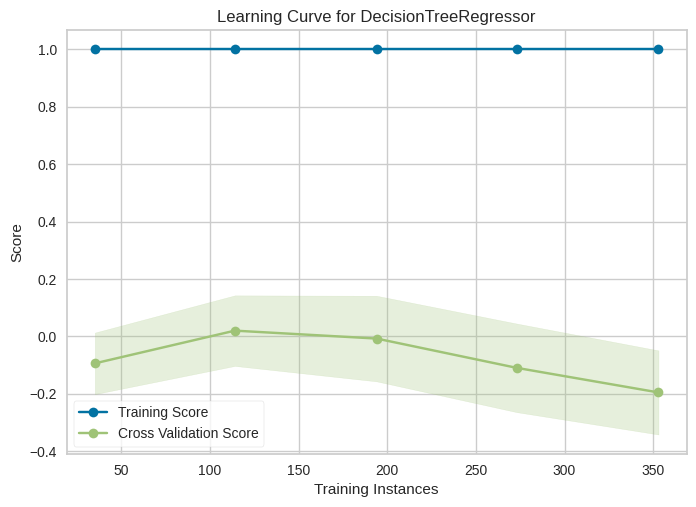

In [16]:
visualizer = LearningCurve(tree_reg_default, scoring='r2')
visualizer.fit(X, y)
visualizer.show();

## Que peut-on déduire de ces courbes ?

Prenez un moment pour comparer les deux courbes ci-dessus :
- **Premier modèle** (`max_depth=4, max_features=3`) : arbre bridé.
- **Second modèle** (`DecisionTreeRegressor()` par défaut) : arbre sans contrainte, maximum de degrés de liberté.

Trois angles d'analyse :

**En termes de taille du jeu d'apprentissage :**
- Jusqu'à quelle taille le score continue-t-il à s'améliorer ? Après, le gain est-il encore significatif ? Ça dit si ça vaut la peine d'aller chercher plus de données.

**En termes d'overfitting / underfitting :**
- L'arbre bridé → les deux courbes se rejoignent relativement près l'une de l'autre → plutôt **underfitting** (bias > variance).
- L'arbre par défaut → énorme écart entre train (quasi parfait) et validation (médiocre) → **overfitting** flagrant (variance > bias).

**En termes de biais / variance :**
- Le premier modèle souffre plus de biais (modèle trop simple).
- Le second modèle souffre plus de variance (modèle trop flexible, qui mémorise).
- **Le modèle idéal est quelque part entre les deux.** D'où l'intérêt d'utiliser la cross-validation pour *chercher* ce bon équilibre en testant plusieurs configurations d'hyperparamètres — c'est exactement ce que fait `GridSearchCV`, qu'on verra bientôt.

## 🎯 La cross-validation en pratique

### Quand l'utiliser ?

**Dans presque tous les cas** où on règle des hyperparamètres ou qu'on compare plusieurs modèles. C'est devenu un **standard** en machine learning. Les exceptions :
- **Deep learning sur très gros dataset** : un simple split train/val/test suffit (la cross-validation est trop coûteuse et les données abondantes rendent le split suffisamment stable).
- **Données temporelles** : on utilise une variante, `TimeSeriesSplit`, qui respecte l'ordre chronologique (on ne peut pas s'entraîner sur le futur pour prédire le passé !).

### Les variantes utiles

| Variante | Quand l'utiliser |
|---|---|
| **`KFold`** (défaut) | Cas général, données indépendantes et mélangées |
| **`StratifiedKFold`** | Classification avec classes déséquilibrées (garde la même proportion de chaque classe dans chaque fold) |
| **`TimeSeriesSplit`** | Séries temporelles (jamais d'info du futur dans l'entraînement) |
| **`GroupKFold`** | Quand plusieurs lignes concernent la même entité (patient, utilisateur) — on veut qu'une entité soit *soit* en train, *soit* en validation, jamais les deux |
| **`LeaveOneOut`** | Très petits datasets (< 50 échantillons) — $k$ = nombre d'échantillons |

### Les pièges à éviter

- ⚠️ **Data leakage** : toutes les transformations (normalisation, imputation, sélection de features) doivent être **apprises sur les données d'entraînement du fold uniquement**, pas sur le jeu entier. Sinon, on « fuite » de l'information depuis la validation vers l'entraînement. Utiliser systématiquement un `Pipeline` scikit-learn pour s'en prémunir :
  ```python
  from sklearn.pipeline import Pipeline
  from sklearn.preprocessing import StandardScaler
  pipe = Pipeline([('scaler', StandardScaler()), ('model', DecisionTreeRegressor())])
  cross_val_score(pipe, X_train, y_train, cv=10)
  ```
- ⚠️ **Données déséquilibrées en classification** : sans `StratifiedKFold`, on peut tomber sur un fold qui ne contient aucune instance d'une classe minoritaire — le score devient absurde.
- ⚠️ **Choix de $k$** : $k = 5$ ou $k = 10$ est le standard. Trop grand ($k = n$, *leave-one-out*) → très coûteux et score très variable. Trop petit ($k = 2$ ou 3) → estimation bruitée.

### Le mot de la fin

> **Regardez toujours la moyenne ET l'écart-type** des scores de cross-validation. Un modèle avec 0,75 ± 0,02 est bien plus fiable qu'un modèle avec 0,78 ± 0,15, même si son score moyen est un peu plus bas. Un fort écart-type = modèle instable = à éviter en production.